In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from dowhy import CausalModel
import networkx as nx

# Задача 1. Backdoor adjustment при двух confounder

Дан наблюдательный датасет `data/task1.csv` с переменными:

- `X` — treatment / воздействие;
- `Y` — outcome / исход;
- `C1`, `C2` — наблюдаемые смешивающие факторы.

Известна структура DAG:

```text
C1 -> X
C2 -> X
C1 -> Y
C2 -> Y
X  -> Y
```


```mermaid
graph LR
    C1 --> X
    C2 --> X
    C1 --> Y
    C2 --> Y
    X --> Y
```

## Требуется

1. Оценить полный каузальный эффект `X` на `Y` "вручную" (с помощью `sm.OLS`):  
   `d E[Y | do(X=x)] / dx`. *Обратите внимание, что в общем случае эффектом называют именно производную (или коэффициент в линейной модели); величину "сколько `X` принёс в `Y`" называют вкладом (contribution).*
2. Показать, что наивная регрессия `Y ~ X` даёт смещённую оценку.
3. С помощью DoWhy:
   - задать causal graph;
   - идентифицировать estimand;
   - оценить эффект методом `backdoor.linear_regression` (знание со стороны: связь линейная);
   - выполнить хотя бы один refutation test.
4. Сделайте `print(estimand)` и объясните что означают предположения (assumptions) для каждого найденного Estimand.


In [3]:
df_1 = pd.read_csv('data/task1.csv')

In [8]:

model_correct = sm.OLS(
    df_1['Y'],
    sm.add_constant(df_1[['X', 'C1', 'C2']])
).fit()

print(model_correct.summary())
print(f"\nКаузальный эффект X на Y (backdoor adjustment): {model_correct.params['X']:.4f}")
print("\n")
model_naive = sm.OLS(
    df_1['Y'],
    sm.add_constant(df_1[['X']])
).fit()

print(model_naive.summary())
print(f"\nНаивная оценка (смещённая): {model_naive.params['X']:.4f}")
print(f"Корректная оценка:{model_correct.params['X']:.4f}")
print(f"Смещение:{model_naive.params['X'] - model_correct.params['X']:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                 3.592e+04
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        21:30:40   Log-Likelihood:                -7090.0
No. Observations:                5000   AIC:                         1.419e+04
Df Residuals:                    4996   BIC:                         1.421e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0082      0.014      0.577      0.5

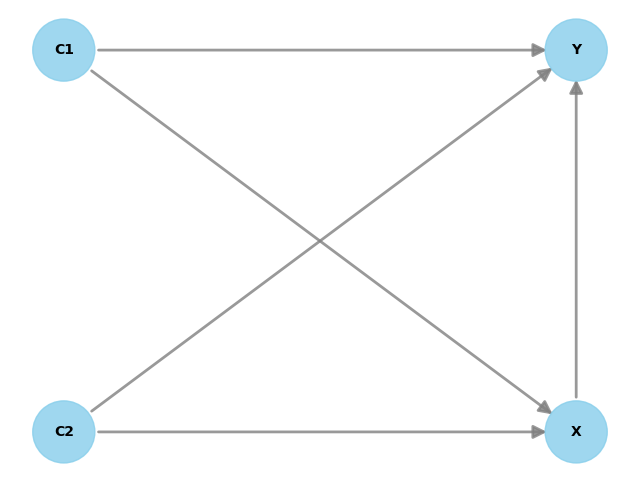

In [11]:

model_dw1 = CausalModel(data=df_1, treatment='X', outcome='Y',
graph=
    """
            digraph {
                C1 -> X;
                C2 -> X;
                C1 -> Y;
                C2 -> Y;
                X  -> Y;
            }
    """
)

model_dw1.view_model()

estimand_1 = model_dw1.identify_effect()



In [ ]:
estimate_1 = model_dw1.estimate_effect(
    estimand_1,
    method_name="backdoor.linear_regression"
)
print(f"\nDoWhy estimate: {estimate_1.value:.4f}")

refute_random = model_dw1.refute_estimate(
    estimand_1,
    estimate_1,
    method_name="random_common_cause"
)
print(refute_random)

refute_placebo = model_dw1.refute_estimate(
    estimand_1,
    estimate_1,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(refute_placebo)


DoWhy estimate: 2.0216
Refute: Add a random common cause
Estimated effect:2.0215679426229323
New effect:2.0215701607018306
p value:0.94

Refute: Use a Placebo Treatment
Estimated effect:2.0215679426229323
New effect:0.00042663590752294885
p value:0.94



In [12]:
print(estimand_1)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d              
────(E[Y|C2,C1])
d[X]            
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,C2,C1,U) = P(Y|X,C2,C1)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
 d              
────(E[Y|C2,C1])
d[X]            
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,C2,C1,U) = P(Y|X,C2,C1)



### Assumptions (Backdoor Estimand, adjust = {C1, C2})

1. **Unconfoundedness** — при обуславливании по C1, C2 все backdoor-пути между X Y заблокированы, скрытого confounding нет.
2. **Positivity** — для любых значений (C1, C2) возможны разные значения X (нет страт, где X фиксирован).
3. **SUTVA** — исход каждого наблюдения зависит только от его собственного treatment.
4. **Верность графа** — нет пропущенных рёбер и скрытых переменных.

# Задача 2. Direct effect и indirect effect через медиатор

Дан наблюдательный датасет `data/task2.csv` с переменными:

- `X` — treatment;
- `M` — mediator;
- `Y` — outcome.

Известна структура DAG:

```text
X -> M
M -> Y
X -> Y
```


```mermaid
graph LR
    X --> M
    M --> Y
    X --> Y
```

## Требуется

1. Оценить вручную полный эффект `X` на `Y`.
2. Вручную разложить эффект на:
   - natural direct effect: путь `X -> Y`
     - коэффициент при `X` в `Y ~ X + M`;
   - natural indirect effect: путь `X -> M -> Y`
     - произведение коэффициента при `X` в `M ~ X` на коэффициент при `M` в `Y ~ X + M`; 
3. С помощью DoWhy:
   - задать causal graph;
   - оценить total effect;
   - оценить NDE и NIE через `estimand_type="nonparametric-nde"` и `"nonparametric-nie"`.
4. Сравнить результат с простой линейной декомпозицией.
5. Сделайте `print(estimand_total), print(estimand_direct), print(estimand_indirect)` и объясните что означают предположения (assumptions) для каждого найденного Estimand.


In [13]:
df_2 = pd.read_csv('data/task2.csv')

In [21]:
model_total = sm.OLS(df_2['Y'], sm.add_constant(df_2[['X']])).fit()
total_effect = model_total.params['X']
print("=== Полный эффект: Y ~ X ===")
print(model_total.summary())
print(f"\n X -> Y    {total_effect}")

print("\n")

=== Полный эффект: Y ~ X ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                 1.062e+04
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        21:51:57   Log-Likelihood:                -10079.
No. Observations:                5000   AIC:                         2.016e+04
Df Residuals:                    4998   BIC:                         2.018e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0051  

In [26]:
model_ym = sm.OLS(df_2['Y'], sm.add_constant(df_2[['X', 'M']])).fit()
nde = model_ym.params['X']

model_mx = sm.OLS(df_2['M'], sm.add_constant(df_2[['X']])).fit()
nie = model_mx.params['X'] * model_ym.params['M']

print("Модель M ~ X")
print(model_mx.summary())
print(f"\nX -> M:   {model_mx.params['X']}")


Модель M ~ X
                            OLS Regression Results                            
Dep. Variable:                      M   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     7598.
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        21:53:52   Log-Likelihood:                -7087.7
No. Observations:                5000   AIC:                         1.418e+04
Df Residuals:                    4998   BIC:                         1.419e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0063      0.014     -0

In [28]:
print("\Модель Y ~ X + M")
print(model_ym.summary())


\Модель Y ~ X + M
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                 2.299e+04
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        21:54:47   Log-Likelihood:                -7121.0
No. Observations:                5000   AIC:                         1.425e+04
Df Residuals:                    4997   BIC:                         1.427e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0045      0.014  

In [29]:
print(f"\nNatural Direct Effect (X -> Y):  {nde}")
print(f"Natural Indirect Effect (X->M->Y):  {nie}")
print(f"Сумма NDE + NIE:  {nde + nie}")
print(f"Total Effect:  {total_effect}")
print(f"Ошибка декомпозиции:  {abs(total_effect - (nde + nie)):.6f}")


Natural Direct Effect (X -> Y):  0.7775209459075874
Natural Indirect Effect (X->M->Y):  1.854802606358304
Сумма NDE + NIE:  2.632323552265891
Total Effect:  2.6323235522658903
Ошибка декомпозиции:  0.000000


In [33]:
model_dw2 = CausalModel(
    data=df_2,
    treatment='X',
    outcome='Y',
    graph="""
    digraph {
        X -> M;
        M -> Y;
        X -> Y;
    }
    """
)

estimand_total = model_dw2.identify_effect(estimand_type="nonparametric-ate")
estimate_total = model_dw2.estimate_effect(
    estimand_total,
    method_name="backdoor.linear_regression"
)
print(f"Total effect: {estimate_total.value:.4f}")

estimand_direct = model_dw2.identify_effect(estimand_type="nonparametric-nde")
estimate_direct = model_dw2.estimate_effect(
    estimand_direct,
    method_name="mediation.two_stage_regression"
)
print(f"NDE (DoWhy): {estimate_direct.value:.4f}")

estimand_indirect = model_dw2.identify_effect(estimand_type="nonparametric-nie")
estimate_indirect = model_dw2.estimate_effect(
    estimand_indirect,
    method_name="mediation.two_stage_regression"
)
print(f"NIE (DoWhy): {estimate_indirect.value:.4f}")

print(f"\nNDE:  {nde:.4f}  |  DoWhy NDE: {estimate_direct.value:.4f}")
print(f"NIE:  {nie:.4f}  |  DoWhy NIE: {estimate_indirect.value:.4f}")
print(f"Total: {total_effect:.4f} | DoWhy Total: {estimate_total.value:.4f}")


Total effect: 2.6323
NDE (DoWhy): 0.7775
NIE (DoWhy): 1.8548

NDE:  0.7775  |  DoWhy NDE: 0.7775
NIE:  1.8548  |  DoWhy NIE: 1.8548
Total: 2.6323 | DoWhy Total: 2.6323


In [35]:
print("\nEstimand: Total Effect")
print(estimand_total)




Estimand: Total Effect
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d        
────(E[Y])
d[X]      
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,,U) = P(Y|X,)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
 d        
────(E[Y])
d[X]      
Estimand assumption 1, Unconfoundedness: If U→{X} and U→Y then P(Y|X,,U) = P(Y|X,)



In [36]:
print("\nEstimand: Natural Direct Effect")
print(estimand_direct)



Estimand: Natural Direct Effect
Estimand type: EstimandType.NONPARAMETRIC_NDE

### Estimand : 1
Estimand name: mediation
Estimand expression:
 ⎡ d       ⎤
E⎢────(Y|M)⎥
 ⎣d[X]     ⎦
Estimand assumption 1, Mediation: M intercepts (blocks) all directed paths from X to Y except the path {X}→{Y}.
Estimand assumption 2, First-stage-unconfoundedness: If U→{X} and U→{M} then P(M|X,U) = P(M|X)
Estimand assumption 3, Second-stage-unconfoundedness: If U→{M} and U→Y then P(Y|M, X, U) = P(Y|M, X)



In [37]:

print("\nEstimand: Natural Indirect Effect")
print(estimand_indirect)


Estimand: Natural Indirect Effect
Estimand type: EstimandType.NONPARAMETRIC_NIE

### Estimand : 1
Estimand name: mediation
Estimand expression:
 ⎡ d       d       ⎤
E⎢────(Y)⋅────([M])⎥
 ⎣d[M]    d[X]     ⎦
Estimand assumption 1, Mediation: M intercepts (blocks) all directed paths from X to Y except the path {X}→{Y}.
Estimand assumption 2, First-stage-unconfoundedness: If U→{X} and U→{M} then P(M|X,U) = P(M|X)
Estimand assumption 3, Second-stage-unconfoundedness: If U→{M} and U→Y then P(Y|M, X, U) = P(Y|M, X)



### Assumptions — Задача 2

**Total Effect (ATE):** confounders нет, adjustment-множество пустое → Y ~ X сразу даёт несмещённый total effect.

**NDE:** прямой эффект X→Y минуя M. Предполагается sequential ignorability (нет скрытого confounding между M и Y) и cross-world consistency (потенциальные исходы из "разных миров" корректно определены). Также нет M–Y confounders, зависящих от X.

**NIE:** непрямой эффект X→M→Y. Те же предположения, что и для NDE. В линейном случае total = NDE + NIE выполняется точно.

# Задача 3. Частично ориентированный граф: confounder, collider или mediator?

Дан наблюдательный датасет `data/task3.csv` с переменными:

- `X` — treatment;
- `M` — известный mediator;
- `Y` — outcome;
- `Q` — дополнительная переменная, роль которой неизвестна.

Известен неориентированный граф:

```text
Q - X
X - M
M - Y
Q - Y
```

Также известно, что:

```text
X -> M -> Y
```

Но неизвестно, как ориентированы рёбра:

```text
Q - X
Q - Y
```

```mermaid
graph LR
    Q --- X
    X --> M
    M --> Y
    Q --- Y
    
```


Кандидаты:

1. `Q` confounder: `Q -> X`, `Q -> Y`;
2. `Q` collider: `X -> Q <- Y`;
3. `Q` ещё один mediator: `X -> Q -> Y`.


Нам уже дан датасет и проводить реальные интервенции мы не можем.

## Требуется

1. Проверить, достаточно ли наблюдательных данных и заданной частичной структуры, чтобы определить роль `Q`.
2. Если структура идентифицируема, обосновать выбор DAG и оценить эффект `X` на `Y`.
3. Если структура не идентифицируема, явно показать минимум два DAG, совместимых с данными и известными ограничениями.
4. Для каждого совместимого DAG указать, по каким переменным можно/нельзя обуславливаться / делать стратификацию / adjust-ить.
5. Сделать вывод: можно ли дать единственную численную оценку `P(Y | do(X=x))` из этих данных без дополнительных предположений.
6. Для каждого совместимого DAG оценить эффект в предположении, что граф именно такой.


In [38]:
df_3 = pd.read_csv('data/task3.csv')

In [39]:
resid_m3 = sm.OLS(df_3['M'], sm.add_constant(df_3[['X']])).fit().resid
resid_q3 = sm.OLS(df_3['Q'], sm.add_constant(df_3[['X']])).fit().resid
partial_qm_x = np.corrcoef(resid_m3, resid_q3)[0, 1]

_, p_value_qm_x = stats.pearsonr(resid_m3, resid_q3)

print("=== Тест: Q ⊥ M | X ===")
print(f"Partial Corr(Q, M | X) = {partial_qm_x:.4f},  p-value = {p_value_qm_x:.4f}")
print()

=== Тест: Q ⊥ M | X ===
Partial Corr(Q, M | X) = 0.0030,  p-value = 0.8322



# Анализ эквивалентности:
1. DAG_confounder: Q->X, Q->Y, X->M, M->Y   (v-structure: Q->Y<-M)
2. DAG_mediator: X->Q, Q->Y, X->M, M->Y   (v-structure: Q->Y<-M)
3. cкелет и v-structures совпадают → DAG-и Markov-эквивалентны
4. из наблюдательных данных нельзя определить роль Q.

In [ ]:

model_conf = sm.OLS(df_3['Y'], sm.add_constant(df_3[['X', 'Q']])).fit()
effect_conf = model_conf.params['X']

model_med = sm.OLS(df_3['Y'], sm.add_constant(df_3[['X']])).fit()
effect_med = model_med.params['X']

print("=== Оценки каузального эффекта X -> Y ===")
print(f"DAG_confounder (Y ~ X + Q, adjust по Q): {effect_conf:.4f}")
print(f"DAG_mediator   (Y ~ X, без adjust):      {effect_med:.4f}")
print()


=== Оценки каузального эффекта X → Y ===
DAG_confounder (Y ~ X + Q, adjust по Q): 1.6914
DAG_mediator   (Y ~ X, без adjust):      2.3456




# --- По каким переменным можно/нельзя adjust-ить ---
- Правила adjust для каждого DAG:
- DAG_confounder (Q -> X, Q -> Y)
- Q — confounder → НУЖНО adjust-ить
- M — медиатор → НЕ adjust-ить (для total effect)

- DAG_mediator (X -> Q -> Y)
- Q — медиатор → НЕ adjust-ить (для total effect)
- M — медиатор → НЕ adjust-ить (для total effect)

# Вывод 
- Нельзя дать единственную численную оценку P(Y|do(X=x))
- без дополнительных предположений о направлении рёбер Q-X, Q-Y.


In [41]:
print(f"Диапазон оценок: [{min(effect_conf, effect_med):.4f}, {max(effect_conf, effect_med):.4f}]")

Диапазон оценок: [1.6914, 2.3456]


In [54]:

model_dw3_conf = CausalModel(
    data=df_3, treatment='X', outcome='Y',
    graph="digraph { Q -> X; Q -> Y; X -> M; M -> Y; }"
)
est3_conf = model_dw3_conf.identify_effect()
eff3_conf = model_dw3_conf.estimate_effect(est3_conf, method_name="backdoor.linear_regression")
print(f"DoWhy DAG_confounder: effect = {eff3_conf.value:.4f}")

model_dw3_med = CausalModel(
    data=df_3, treatment='X', outcome='Y',
    graph="digraph { X -> Q; Q -> Y; X -> M; M -> Y; }"
)
est3_med = model_dw3_med.identify_effect()
eff3_med = model_dw3_med.estimate_effect(est3_med, method_name="backdoor.linear_regression")
print(f"DoWhy DAG_mediator:   effect = {eff3_med.value:.4f}")

DoWhy DAG_confounder: effect = 1.6914
DoWhy DAG_mediator:   effect = 2.3456


# Задача 4. Частично ориентированный граф: confounder, collider или mediator?

Дан наблюдательный датасет `data/task4.csv` с переменными:

- `X` — treatment;
- `M` — известный mediator;
- `Y` — outcome;
- `Q` — дополнительная переменная, роль которой неизвестна.

Известен неориентированный граф:

```text
Q - X
X - M
M - Y
Q - Y
```

Также известно, что:

```text
X -> M -> Y
```

Но неизвестно, как ориентированы рёбра:

```text
Q - X
Q - Y
```

```mermaid
graph LR
    Q --- X
    X --> M
    M --> Y
    Q --- Y
    
```

Кандидаты:

1. `Q` — confounder: `Q -> X`, `Q -> Y`;
2. `Q` — collider: `X -> Q <- Y`;
3. `Q` — ещё один mediator: `X -> Q -> Y`.


Нам уже дан датасет и проводить реальные интервенции мы не можем.

## Требуется

1. Проверить, достаточно ли наблюдательных данных и заданной частичной структуры, чтобы определить роль `Q`.
2. Если структура идентифицируема, обосновать выбор DAG и оценить эффект `X` на `Y`.
3. Если структура не идентифицируема, явно показать минимум два DAG, совместимых с данными и известными ограничениями.
4. Для каждого совместимого DAG указать, по каким переменным можно/нельзя обуславливаться / делать стратификацию / adjust-ить.
5. Сделать вывод: можно ли дать единственную численную оценку `P(Y | do(X=x))` из этих данных без дополнительных предположений.
6. Для каждого совместимого DAG оценить эффект в предположении, что граф именно такой.


In [55]:
df_4 = pd.read_csv('data/task4.csv')

In [59]:

resid_m4 = sm.OLS(df_4['M'], sm.add_constant(df_4[['X']])).fit().resid
resid_q4 = sm.OLS(df_4['Q'], sm.add_constant(df_4[['X']])).fit().resid
partial_qm_x_4 = np.corrcoef(resid_m4, resid_q4)[0, 1]
_, p_val_4 = stats.pearsonr(resid_m4, resid_q4)

print(f"Partial Corr(Q, M | X) = {partial_qm_x_4:.4f},  p-value = {p_val_4:.2e}")

print("Только Collider DAG (X -> Q <- Y) совместим с данными!")
print("Confounder и Mediator исключены\n")


print("Идентифицированный DAG")
print("X -> M -> Y  (каузальный путь)")
print("X -> Q <- Y  (Q — коллайдер)\n")


print("Правила adjust")
print("Q — коллайдер -> НЕЛЬЗЯ adjust-ить введёт collider bias")
print("M — медиатор -> НЕ adjust-ить для total effect\n")



Partial Corr(Q, M | X) = 0.7499,  p-value = 0.00e+00
Только Collider DAG (X -> Q <- Y) совместим с данными!
Confounder и Mediator исключены

Идентифицированный DAG
X -> M -> Y  (каузальный путь)
X -> Q <- Y  (Q — коллайдер)

Правила adjust
Q — коллайдер -> НЕЛЬЗЯ adjust-ить введёт collider bias
M — медиатор -> НЕ adjust-ить для total effect



In [60]:

model_t4_correct = sm.OLS(df_4['Y'], sm.add_constant(df_4[['X']])).fit()
effect_t4 = model_t4_correct.params['X']
print(f"Каузальный эффект X -> Y (Y ~ X): {effect_t4:.4f}")

model_t4_biased = sm.OLS(df_4['Y'], sm.add_constant(df_4[['X', 'Q']])).fit()
effect_t4_biased = model_t4_biased.params['X']
print(f"Смещённая оценка (adjust по Q): {effect_t4_biased:.4f}")
print(f"Collider bias: {effect_t4_biased - effect_t4:.4f}\n")

print("Структура однозначно идентифицируема: Q — коллайдер.")
print(f"Единственная оценка каузального эффекта: {effect_t4:.4f}")

Каузальный эффект X -> Y (Y ~ X): 1.6869
Смещённая оценка (adjust по Q): -0.3951
Collider bias: -2.0820

Структура однозначно идентифицируема: Q — коллайдер.
Единственная оценка каузального эффекта: 1.6869


In [61]:
model_dw4 = CausalModel(
    data=df_4, treatment='X', outcome='Y',
    graph="digraph { X -> Q; Y -> Q; X -> M; M -> Y; }"
)

est4 = model_dw4.identify_effect()
eff4 = model_dw4.estimate_effect(est4, method_name="backdoor.linear_regression")
print(f"DoWhy Collider DAG: effect = {eff4.value:.4f}")

refute4 = model_dw4.refute_estimate(est4, eff4, method_name="random_common_cause")
print(refute4)

DoWhy Collider DAG: effect = 1.6869
Refute: Add a random common cause
Estimated effect:1.6868620975861672
New effect:1.686891332443092
p value:0.8999999999999999



# Задача 5. Частично ориентированный граф: confounder, collider или mediator?

Дан наблюдательный датасет `data/task5.csv` с переменными:

- `X` — treatment;
- `M` — известный mediator;
- `Y` — outcome;
- `Q` — дополнительная переменная, роль которой неизвестна.

Известен неориентированный граф:

```text
Q - X
X - M
M - Y
Q - Y
```

Также известно, что:

```text
X -> M -> Y
```

Но неизвестно, как ориентированы рёбра:

```text
Q - X
Q - Y
```

```mermaid
graph LR
    Q --- X
    X --> M
    M --> Y
    Q --- Y
    
```

Кандидаты:

1. `Q` — confounder: `Q -> X`, `Q -> Y`;
2. `Q` — collider: `X -> Q <- Y`;
3. `Q` — ещё один mediator: `X -> Q -> Y`.


Нам уже дан датасет и проводить реальные интервенции мы не можем.

## Требуется

1. Проверить, достаточно ли наблюдательных данных и заданной частичной структуры, чтобы определить роль `Q`.
2. Если структура идентифицируема, обосновать выбор DAG и оценить эффект `X` на `Y`.
3. Если структура не идентифицируема, явно показать минимум два DAG, совместимых с данными и известными ограничениями.
4. Для каждого совместимого DAG указать, по каким переменным можно/нельзя обуславливаться / делать стратификацию / adjust-ить.
5. Сделать вывод: можно ли дать единственную численную оценку `P(Y | do(X=x))` из этих данных без дополнительных предположений.
6. Для каждого совместимого DAG оценить эффект в предположении, что граф именно такой.


In [62]:
df_5 = pd.read_csv('data/task5.csv')

In [64]:

resid_m5 = sm.OLS(df_5['M'], sm.add_constant(df_5[['X']])).fit().resid
resid_q5 = sm.OLS(df_5['Q'], sm.add_constant(df_5[['X']])).fit().resid
partial_qm_x_5 = np.corrcoef(resid_m5, resid_q5)[0, 1]
_, p_val_5 = stats.pearsonr(resid_m5, resid_q5)

print(f"Partial Corr(Q, M | X) = {partial_qm_x_5:.4f},  p-value = {p_val_5:.4f}")
print("Collider ИСКЛЮЧЁН")

Partial Corr(Q, M | X) = -0.0122,  p-value = 0.3897
Collider ИСКЛЮЧЁН


- DAG_confounder: Q->X, Q->Y, X->M, M->Y   (v-structure: Q->Y<-M)
- DAG_mediator:   X->Q, Q->Y, X->M, M->Y   (v-structure: Q->Y<-M)
- Из наблюдательных данных НЕЛЬЗЯ определить роль Q


In [ ]:

# --- Шаг 3-4. Оценки для каждого DAG ---
model_conf5 = sm.OLS(df_5['Y'], sm.add_constant(df_5[['X', 'Q']])).fit()
effect_conf5 = model_conf5.params['X']

model_med5 = sm.OLS(df_5['Y'], sm.add_constant(df_5[['X']])).fit()
effect_med5 = model_med5.params['X']

print("=== Оценки каузального эффекта X -> Y ===")
print(f"DAG_confounder (Y ~ X + Q, adjust по Q): {effect_conf5:.4f}")
print(f"DAG_mediator   (Y ~ X, без adjust):      {effect_med5:.4f}")


print("=== Правила adjust для каждого DAG ===")
print("DAG_confounder (Q -> X, Q -> Y):")
print("  Q — confounder -> НУЖНО adjust-ить")
print("  M — медиатор -> НЕ adjust-ить (для total effect)")

print("DAG_mediator (X -> Q -> Y):")
print("  Q — медиатор -> НЕ adjust-ить (для total effect)")

print("Нельзя дать единственную численную оценку P(Y|do(X=x))")
print("без дополнительных предположений о направлении рёбер Q-X, Q-Y.")
print(f"Диапазон оценок: [{min(effect_conf5, effect_med5):.4f}, {max(effect_conf5, effect_med5):.4f}]")

=== Оценки каузального эффекта X -> Y ===
DAG_confounder (Y ~ X + Q, adjust по Q): 1.7320
DAG_mediator   (Y ~ X, без adjust):      2.8773
=== Правила adjust для каждого DAG ===
DAG_confounder (Q -> X, Q -> Y):
  Q — confounder → НУЖНО adjust-ить
  M — медиатор → НЕ adjust-ить (для total effect)
DAG_mediator (X -> Q -> Y):
  Q — медиатор → НЕ adjust-ить (для total effect)
Нельзя дать единственную численную оценку P(Y|do(X=x))
без дополнительных предположений о направлении рёбер Q-X, Q-Y.
Диапазон оценок: [1.7320, 2.8773]


In [66]:

model_dw5_conf = CausalModel(
    data=df_5, treatment='X', outcome='Y',
    graph="digraph { Q -> X; Q -> Y; X -> M; M -> Y; }"
)
est5_conf = model_dw5_conf.identify_effect()
eff5_conf = model_dw5_conf.estimate_effect(est5_conf, method_name="backdoor.linear_regression")
print(f"DoWhy DAG_confounder: effect = {eff5_conf.value:.4f}")

model_dw5_med = CausalModel(
    data=df_5, treatment='X', outcome='Y',
    graph="digraph { X -> Q; Q -> Y; X -> M; M -> Y; }"
)
est5_med = model_dw5_med.identify_effect()
eff5_med = model_dw5_med.estimate_effect(est5_med, method_name="backdoor.linear_regression")
print(f"DoWhy DAG_mediator:   effect = {eff5_med.value:.4f}")

DoWhy DAG_confounder: effect = 1.7320
DoWhy DAG_mediator:   effect = 2.8773


# Задача 6. Ориентация рёбер по необратимым функциональным зависимостям

Дан наблюдательный датасет `data/task6.csv` с дискретными переменными: `A`, `B`, `C`, `D`.

Названия переменных специально не несут предметного смысла.

Известен только неориентированный граф:

```text
A - B
B - C
A - C
C - D
```

```text
A  -  B
 \   /
   C
   |
   D
```


```mermaid
graph LR
    A --- B
    B --- C
    A --- C
    C --- D
    
```

В этой задаче известно дополнительное предметное предположение:

> Если между двумя соседними узлами есть точная необратимая функциональная зависимость, то стрелка направлена от более информативной переменной к менее информативной.  
> Иначе говоря, если `V = f(U)`, но `U` не является функцией `V`, то `σ(V) ⊂ σ(U)`, и ребро ориентируется как `U -> V`.

## Требуется

1. Для каждого ребра проверить обе гипотезы:
   - является ли правая переменная функцией левой;
   - является ли левая переменная функцией правой.
2. Ориентировать все рёбра, где это возможно по критерию вложенности σ-алгебр.
3. Составить полученный DAG.
4. Указать какие выводы являются строго следствиями наблюдательных данных и функционального предположения. В каком случае наличие функциональной зависимости нельзя использовать для ориентирования ребра?

## Подсказка

Для дискретных данных проверка `V = f(U)` сводится к вопросу:

> Для каждого значения `U` наблюдается ровно одно значение `V`?

В pandas это можно проверить через:

```python
df.groupby("U")["V"].nunique().max() == 1
```


In [67]:
df_6 = pd.read_csv('data/task6.csv')

In [69]:
for c in df_6.columns:
    print(f"  {c}: {df_6[c].nunique()} уникальных значений, диапазон [{df_6[c].min()}, {df_6[c].max()}]")
print()

  A: 16 уникальных значений, диапазон [0, 15]
  B: 32 уникальных значений, диапазон [0, 31]
  C: 4 уникальных значений, диапазон [0, 3]
  D: 2 уникальных значений, диапазон [0, 1]



In [72]:
edges = [('A', 'B'), ('B', 'C'), ('A', 'C'), ('C', 'D')]

oriented_edges = []
for u, v in edges:
    v_is_func_of_u = df_6.groupby(u)[v].nunique().max() == 1
    u_is_func_of_v = df_6.groupby(v)[u].nunique().max() == 1

    print(f"Ребро {u}—{v}:")
    print(f"  {v} = f({u})? {'Да' if v_is_func_of_u else 'Нет'}")
    print(f"  {u} = f({v})? {'Да' if u_is_func_of_v else 'Нет'}")

    if v_is_func_of_u and not u_is_func_of_v:
        print(f"  => Необратимая зависимость: sigma({v}) c sigma({u}) => {u} -> {v}")
        oriented_edges.append((u, v))
    elif u_is_func_of_v and not v_is_func_of_u:
        print(f"  => Необратимая зависимость: sigma({u}) c sigma({v}) => {v} -> {u}")
        oriented_edges.append((v, u))
    elif v_is_func_of_u and u_is_func_of_v:
        print(" => Биекция! Нельзя ориентировать по этому критерию.")
    else:
        print(" => Нет функциональной зависимости ни в одну сторону.")

Ребро A—B:
  B = f(A)? Нет
  A = f(B)? Да
  => Необратимая зависимость: sigma(A) c sigma(B) => B -> A
Ребро B—C:
  C = f(B)? Да
  B = f(C)? Нет
  => Необратимая зависимость: sigma(C) c sigma(B) => B -> C
Ребро A—C:
  C = f(A)? Да
  A = f(C)? Нет
  => Необратимая зависимость: sigma(C) c sigma(A) => A -> C
Ребро C—D:
  D = f(C)? Да
  C = f(D)? Нет
  => Необратимая зависимость: sigma(D) c sigma(C) => C -> D


In [74]:
for src, dst in oriented_edges:
    print(f"  {src} -> {dst}")
#DAG

  B -> A
  B -> C
  A -> C
  C -> D


C:\Users\bobin\AppData\Local\Temp\ipykernel_11504\1423441679.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


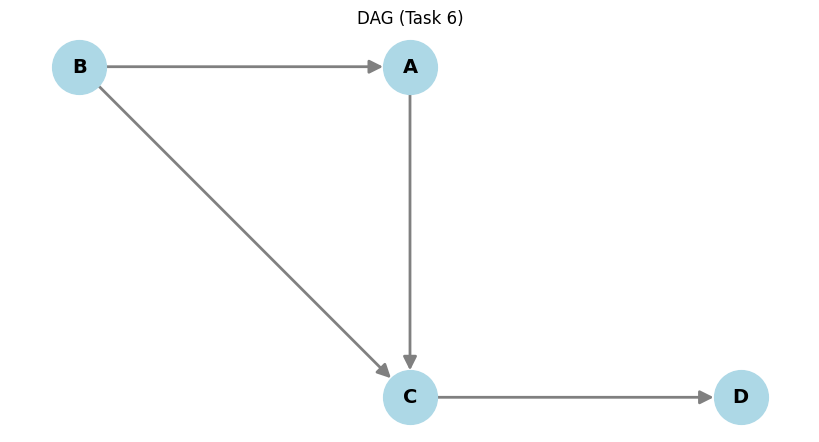

In [ ]:
G = nx.DiGraph()
G.add_edges_from(oriented_edges)

plt.figure(figsize=(8, 4))
pos = {'B': (0, 1), 'A': (1, 1), 'C': (1, 0), 'D': (2, 0)}
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500,
        font_size=14, font_weight='bold', arrows=True, arrowsize=20,
        edge_color='gray', width=2)
plt.title("DAG (Task 6)")
plt.tight_layout()
plt.show()



Ориентирование по функциональной зависимости НЕЛЬЗЯ применить, если зависимость является биекцией (взаимно однозначной): V = f(U) И U = g(V), т.е. sigma(V) = sigma(U). \
В таком случае информационного критерия недостаточно для определения
направления причинности.